In [11]:
import sys, os
sys.path.append(os.path.abspath(".."))


In [12]:
import pandas as pd

df = pd.read_csv("../data/raw/tweets.csv", encoding='latin-1', header=None)
df = df.iloc[:200]

texts = df.iloc[:, 5].astype(str).tolist()

In [13]:
from src.preprocessing import clean_text

texts = [clean_text(t) for t in texts]

In [14]:
from src.embedding import get_bert

embeddings = get_bert(texts)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5537.35it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
from src.similarity import compute_similarity

sim = compute_similarity(embeddings)

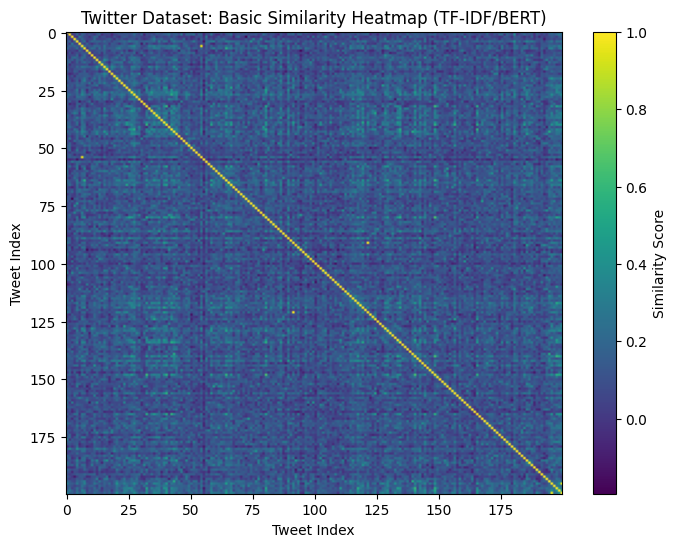

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(sim, aspect='auto')
plt.title("Twitter Dataset: Basic Similarity Heatmap (TF-IDF/BERT)")
plt.colorbar(label="Similarity Score")
plt.xlabel("Tweet Index")
plt.ylabel("Tweet Index")
plt.show()

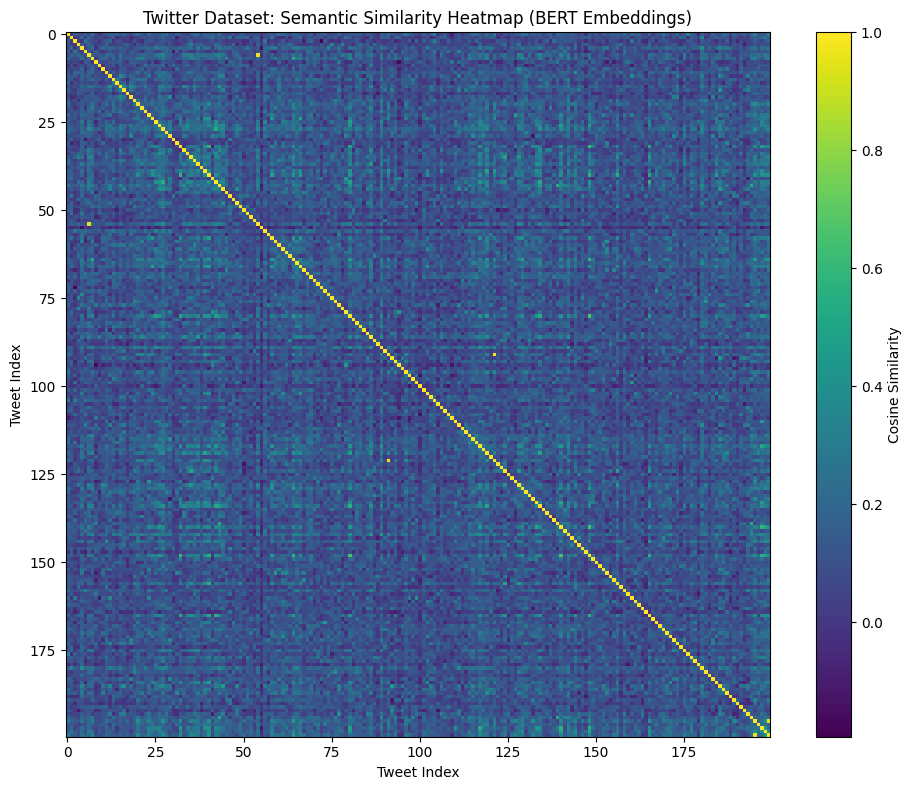

In [17]:
plt.figure(figsize=(10, 8))
plt.imshow(sim, cmap='viridis', interpolation='nearest')
plt.title("Twitter Dataset: Semantic Similarity Heatmap (BERT Embeddings)")
plt.colorbar(label="Cosine Similarity")
plt.xlabel("Tweet Index")
plt.ylabel("Tweet Index")
plt.tight_layout()
plt.show()

In [20]:
from src.graph_builder import build_graph
from src.community import detect_communities

G = build_graph(sim, texts, threshold=0.1)
partition = detect_communities(G)

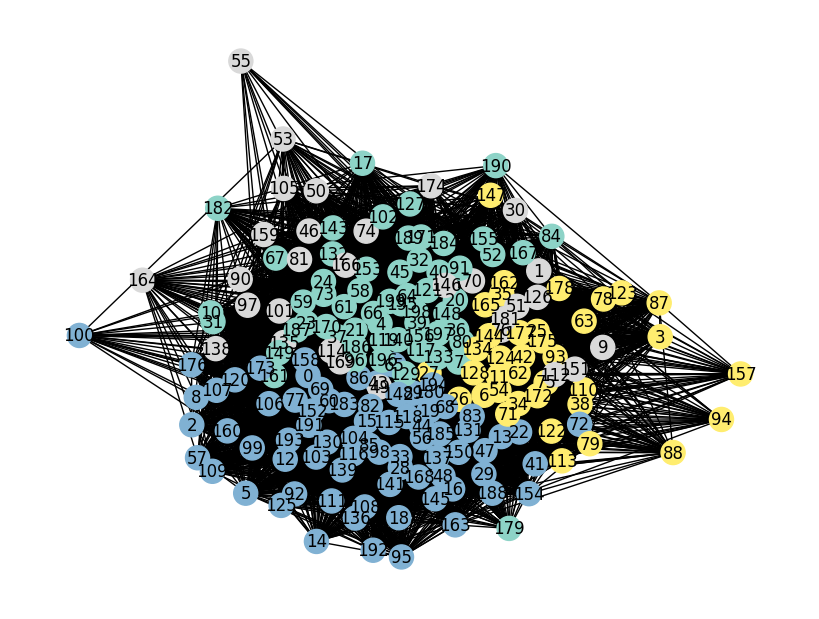

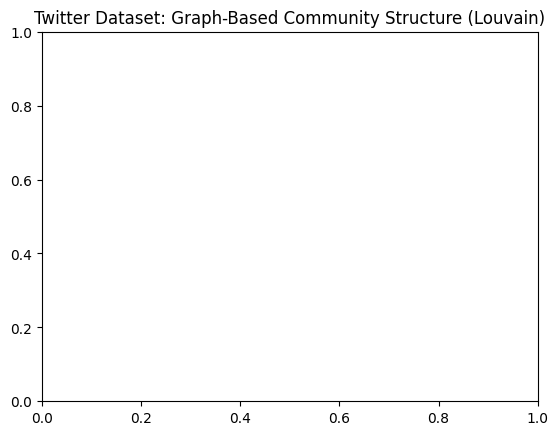

In [24]:
from src.visualize import draw_graph

plt.figure(figsize=(8, 6))
draw_graph(G, partition)
plt.title("Twitter Dataset: Graph-Based Community Structure (Louvain)")
plt.show()

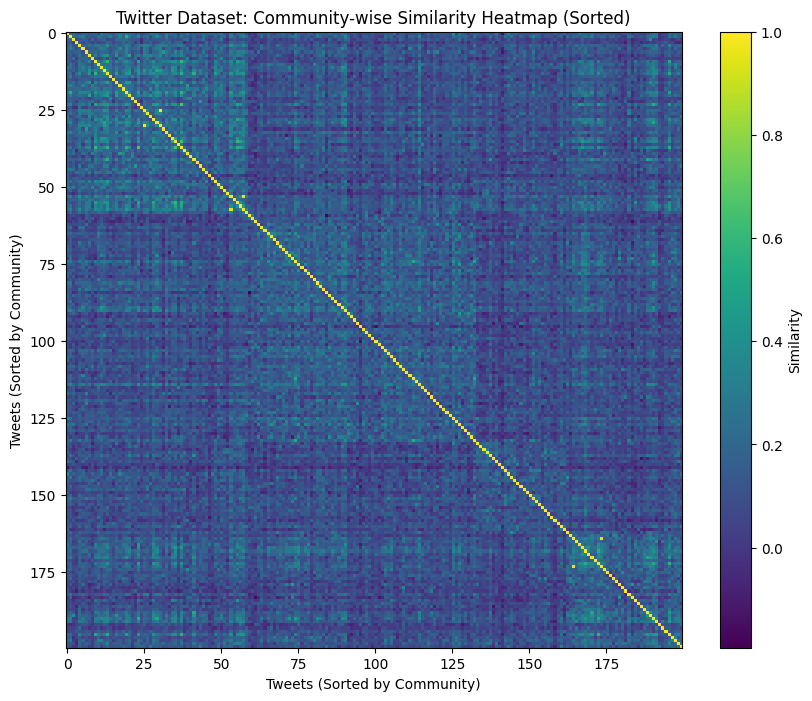

In [22]:
import numpy as np

# Sort nodes by detected community
sorted_nodes = sorted(partition.keys(), key=lambda x: partition[x])

# Reorder similarity matrix
sim_sorted = sim[np.ix_(sorted_nodes, sorted_nodes)]

plt.figure(figsize=(10, 8))
plt.imshow(sim_sorted, cmap='viridis')
plt.title("Twitter Dataset: Community-wise Similarity Heatmap (Sorted)")
plt.colorbar(label="Similarity")
plt.xlabel("Tweets (Sorted by Community)")
plt.ylabel("Tweets (Sorted by Community)")
plt.show()

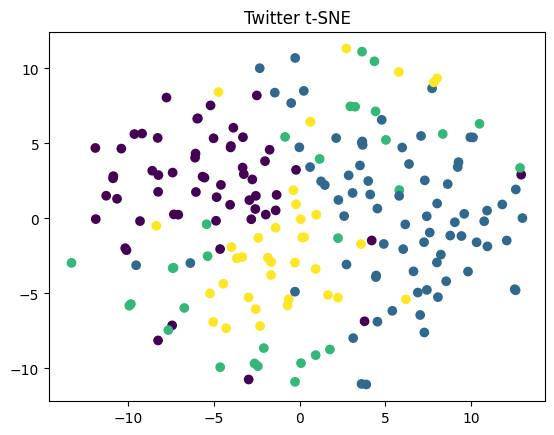

In [23]:
from sklearn.manifold import TSNE

emb_2d = TSNE(n_components=2, perplexity=30).fit_transform(embeddings)

colors = [partition[i] for i in range(len(partition))]

plt.scatter(emb_2d[:,0], emb_2d[:,1], c=colors)
plt.title("Twitter t-SNE")
plt.show()